# Seva testing

#### 1. Get data from dataloader.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from seva.data.mvh_dataloader import MVHumanNetDataset
from torch.utils.data import DataLoader

# load dataset + dataloader
def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

dataset = MVHumanNetDataset(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=8,
    step_size=60,
    only_include=expand_only_include("100001-100500"),
    preload_path="/workspace/datasetvol/mvhuman_data/mv_captures/preloaded_filepaths.json",
    synthetic_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    random_crop=True,
    maximal_crop=True,
    use_inconsistent=True,
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

100001 100500
Loading preloaded filepaths...


Loading scenes:  30%|███       | 827/2749 [00:00<00:00, 3755.43it/s]

Error loading subject 100364 camera CC32871A056 timestep 301: '1505'


Loading scenes: 100%|██████████| 2749/2749 [00:00<00:00, 3528.54it/s]


Loading preloaded filepaths completed!


/usr/local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


MVHN::init done!


### 2. Load model and get logged config & checkpoint.

In [3]:
# INPUT: logdir that contains the model checkpoint + config
from omegaconf import OmegaConf
from sgm.util import instantiate_from_config
import os

# required inputs
log_path = "/workspace/stonevol/logs/2025-09-04T23-54-11_example_training-overfit-r256-512-lr-5"
checkpoint_name = "epoch=024999.ckpt"

# get config
filename_base = os.path.basename(log_path).split("_")[0]
run_config = OmegaConf.load(f"{log_path}/configs/{filename_base}-project.yaml")
ckpt_path = f"{log_path}/checkpoints/{checkpoint_name}"

model_config = run_config.model
# parameters to change (from config)
model_config.params.sampler_config.params.guider_config.params.cfg_min = 1.0

# pretty print for debugging
# import pprint
# pprint.pprint(OmegaConf.to_container(model_config))

In [4]:

from sgm.models.diffusion import DiffusionEngine

engine = instantiate_from_config(run_config.model)
engine.init_from_ckpt(ckpt_path)
engine.eval()

model.safetensors:   0%|          | 0.00/5.06G [00:00<?, ?B/s]

Initialized embedder #0: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #1: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #2: IdentityEncoder with 0 params. Trainable: False
Initialized embedder #3: IdentityEncoder with 0 params. Trainable: False


open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

Initialized embedder #4: SevaFrozenOpenCLIPImageEmbedder with 683800065 params. Trainable: False


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Restored from /workspace/stonevol/logs/2025-09-04T23-54-11_example_training-overfit-r256-512-lr-5/checkpoints/epoch=024999.ckpt with 0 missing and 0 unexpected keys


DiffusionEngine(
  (model): SevaWrapper(
    (diffusion_model): SevaLoRAWrapper(
      (seva_model): Seva(
        (time_embed): Sequential(
          (0): Linear(in_features=320, out_features=1280, bias=True)
          (1): SiLU()
          (2): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (input_blocks): ModuleList(
          (0): TimestepEmbedSequential(
            (0): Conv2d(16, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (1-2): 2 x TimestepEmbedSequential(
            (0): ResBlock(
              (in_layers): Sequential(
                (0): GroupNorm32(32, 320, eps=1e-05, affine=True)
                (1): SiLU()
                (2): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
              (emb_layers): Sequential(
                (0): SiLU()
                (1): Linear(in_features=1280, out_features=320, bias=True)
              )
              (dense_emb_layers): Sequential(


### 3. Run inference using our proposed model
Note that we are still able to change the CFG after instantiating the model.

In [ ]:
import torch 

def all_items_to_gpu(batch):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to("cuda")
    return batch

batch = all_items_to_gpu(next(iter(loader)))
engine = engine.to("cuda")
samples = engine.infer(batch).squeeze(0)

/usr/local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


after prepare batch
cuda:0
cuda:0


torch.Size([8, 3, 576, 576])


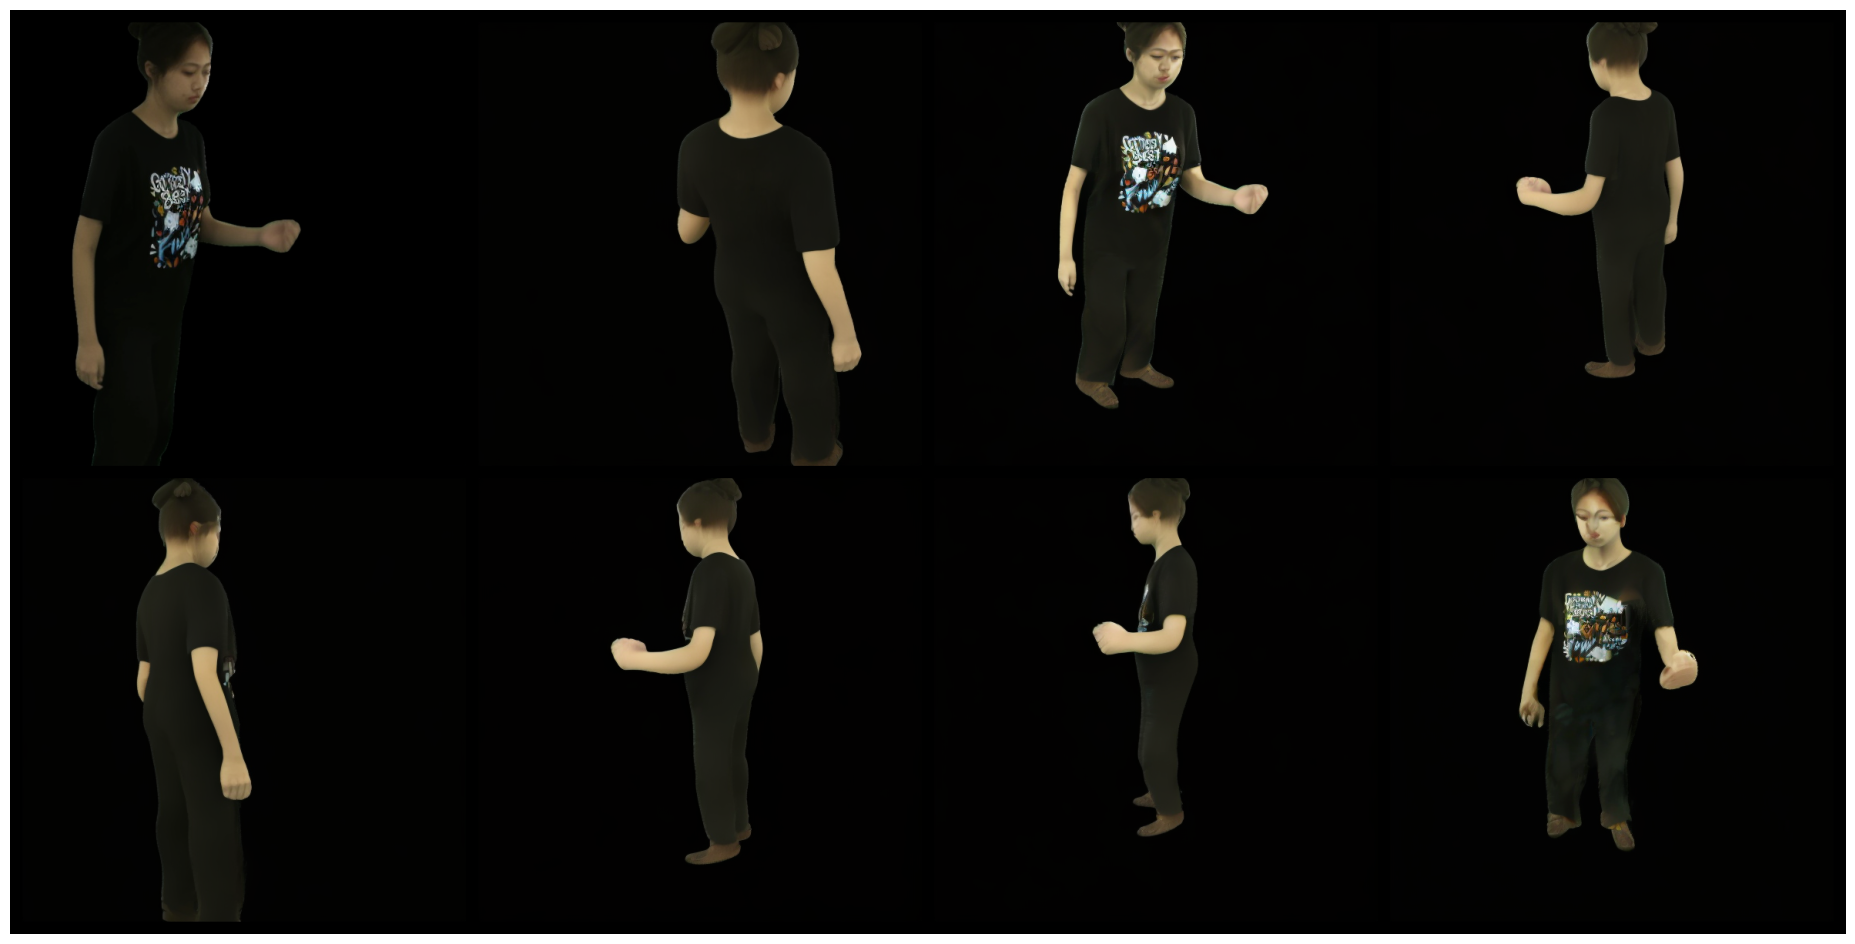

In [ ]:
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

decoded_samples = normalize_tensor(engine.decode_first_stage(samples.squeeze(0))).to("cpu")
_ = show_tensor_batch(decoded_samples)


#### 2. Load Diffusion modules.

In [2]:
from eval_utils import init_seva

vanilla = False
model_components = init_seva(vanilla=vanilla, config_path="configs/example_training/seva-inf.yaml")
ref_path = None

layers of seva are FROZEN


Alternatively, we read from a "transforms.json" and generate for a single batch:

In [3]:
from eval_utils import create_batch_manually

# we can also select from Dl3DV directly 
# NOTE: creates files in the colmap directory as a side effect
# batch = create_batch_manually(
#     colmap_dir="/home/stone/dev/datasets/dl3dv_samples/dl3dv-colmap-new/1K/d4daae84f6b64d1e62fdfd928aac31741fcefc292a8585f6c01197cd885e1a5c/colmap",
#     output_dir="assets_demo_cli/dl3dv_chair_scene_5",
#     images_dir="/home/stone/dev/datasets/dl3dv_samples/dl3dv-480P-new/1K/d4daae84f6b64d1e62fdfd928aac31741fcefc292a8585f6c01197cd885e1a5c/images_8",
#     image_folder="images_8",
#     train_ids=[146, 244, 22, 13, 8],
#     test_ids=[54, 237, 4],
#     autoencoder=model_components["autoencoder"],
#     downsample=8
# )

batch = torch.load("decent_batches/decent_batch3.pt")
    

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_camera_poses(transforms_json_path):
    # Load the transforms.json file
    with open(transforms_json_path, 'r') as f:
        data = json.load(f)
    
    # The file may have a "frames" key or just be a list of dicts
    if isinstance(data, dict) and "frames" in data:
        frames = data["frames"]
    elif isinstance(data, list):
        frames = data
    else:
        # Try to find all dicts with "transform_matrix"
        frames = [x for x in data if isinstance(x, dict) and "transform_matrix" in x]

    cam_centers = []
    x_axes = []
    y_axes = []
    z_axes = []
    for frame in frames:
        mat = np.array(frame["transform_matrix"])
        # Camera center in world coordinates is the translation part
        cam_center = mat[:3, 3]
        # Camera axes in world coordinates: columns 0,1,2 of rotation
        x_axis = mat[:3, 0]  # right
        y_axis = mat[:3, 1]  # up
        z_axis = mat[:3, 2]  # forward (camera -Z is look direction)
        cam_centers.append(cam_center)
        x_axes.append(x_axis)
        y_axes.append(y_axis)
        z_axes.append(z_axis)

    cam_centers = np.stack(cam_centers)
    x_axes = np.stack(x_axes)
    y_axes = np.stack(y_axes)
    z_axes = np.stack(z_axes)

    # Compute scale based on scene size
    scene_extent = np.linalg.norm(cam_centers.max(axis=0) - cam_centers.min(axis=0))
    scale = 0.04 * scene_extent if scene_extent > 0 else 1.0

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2], c='b', label='Camera Centers')

    # Draw camera axes for each pose
    for c, x, y, z in zip(cam_centers, x_axes, y_axes, z_axes):
        # X axis (red)
        ax.quiver(c[0], c[1], c[2], x[0], x[1], x[2], length=scale, color='r', arrow_length_ratio=0.1, linewidth=1, label='X axis' if 'X axis' not in ax.get_legend_handles_labels()[1] else "")
        # Y axis (green)
        ax.quiver(c[0], c[1], c[2], y[0], y[1], y[2], length=scale, color='g', arrow_length_ratio=0.1, linewidth=1, label='Y axis' if 'Y axis' not in ax.get_legend_handles_labels()[1] else "")
        # Z axis (blue, forward)
        ax.quiver(c[0], c[1], c[2], z[0], z[1], z[2], length=scale, color='b', arrow_length_ratio=0.1, linewidth=1, label='Z axis' if 'Z axis' not in ax.get_legend_handles_labels()[1] else "")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Camera Poses from transforms.json')
    # Only show unique legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())
    plt.show()

# Example usage:
# plot_camera_poses("/home/stone/dev/projects/qc_avatar/stable-virtual-camera/assets_demo_cli/re10k-000c3ab189999a83/transforms.json")
plot_camera_poses("/home/stone/dev/projects/qc_avatar/stable-virtual-camera/assets_demo_cli/dl3dv_chair_scene/transforms.json")


In [6]:
from eval_utils import load_from_transforms_json_and_split


# ref_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/assets_demo_cli/garden_flythrough" 
# ref_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/assets_demo_cli/dl3d140-165f5af8bfe32f70595a1c9393a6e442acf7af019998275144f605b89a306557" 

# if ref_path is not None:
#     batch = load_from_transforms_json_and_split(
#         transforms_json_path=ref_path,
#         # num_train_images=3,
#         num_train_images=4,
#         autoencoder=model_components["autoencoder"],
#     )
# else:
#     batch = next(iter(loader))

#### 3. Run model

In [7]:
from eval_utils import run_seva_sample
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch

keep_batch = 1

if not keep_batch:
    batch = next(iter(loader))


batch = {k: v.to("cuda") for k, v in batch.items()}

samples, frames, input_masks = run_seva_sample(batch, model_components, cfg=2.0, vanilla=vanilla)

if samples.shape[1] == 4:
    from seva.modules.autoencoder import AutoEncoder
    ae = AutoEncoder().eval().to("cuda")
    samples = ae.decode(samples)

samples = normalize_tensor(samples).to("cpu")
frames = normalize_tensor(frames).to("cpu")
input_masks = input_masks.to("cpu")

In [ ]:
# plots samples, then GTS
_ = show_tensor_batch(samples, masks=input_masks)
_ = show_tensor_batch(frames, masks=input_masks)


4. Evaluate generations

In [ ]:
from eval_utils import show_tensor_batch, load_image_directory_as_tensor

input_ref, _ = load_image_directory_as_tensor(
    image_dir="/home/stone/dev/projects/qc_avatar/outT8/demo/img2img/dl3dv_chair_scene_5/input",
    image_ext='*.png',
    device='cpu'
)

ref, _ = load_image_directory_as_tensor(
    image_dir="/home/stone/dev/projects/qc_avatar/outT8/demo/img2img/dl3dv_chair_scene_5/samples-rgb",
    image_ext='*.png',
    device='cpu'
)

# permute_vec = torch.tensor([0,4,1,2,5,6,3,7])

_ = show_tensor_batch(torch.cat([input_ref, ref ], dim=0)[permute_vec], masks=input_masks)

In [ ]:
from eval_utils import create_heatmap
from eval_utils import eval_report
from eval_utils import load_image_directory_as_tensor

# ref_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/dl3dv_chair_scene_img2img_4_T8"
ref_path = False
ref_samples_path = None
# ref_samples_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/dl3dv_chair_scene_5_T8/demo/img2img/dl3dv_chair_scene_5/samples-rgb"
if ref_path: 
    # ref_samples_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/garden_flythrough_img2img_5_T16/demo/img2img/garden_flythrough/samples-rgb"
    # ref_samples_path = "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/dl3dv_chair_scene_img2img_4_T8/demo/img2img/dl3dv_chair_scene/samples-rgb"
    ref, _ = load_image_directory_as_tensor(
        image_dir=ref_samples_path,
        image_ext='*.png',
        device='cpu'
    )

samples = samples.to(torch.float32)

metrics, diffmap_plot = eval_report(samples, frames, input_masks, T=input_masks.shape[-1], reference=ref if ref_path else None)

In [ ]:
from eval_utils import run_seva_sample
from eval_utils import normalize_tensor
from eval_utils import show_tensor_batch


def run_one_scene(batch, model_components, cfg=2.0):
    samples, frames, input_masks = run_seva_sample(batch, model_components, cfg=cfg)
    samples = normalize_tensor(samples).to("cpu")
    frames = normalize_tensor(frames).to("cpu")
    input_masks = input_masks.to("cpu")
    # plots samples, then GTS
    _samples_plot = show_tensor_batch(samples, masks=input_masks)
    _gt_plot = show_tensor_batch(frames, masks=input_masks)
    samples = samples.to(torch.float32)
    means, grid = eval_report(samples, frames, input_masks, T=input_masks.shape[-1],
        reference=ref if ref_samples_path else None)
    return means, grid

# spam for next scenes
# batch = next(iter(loader))
means, diffmap = run_one_scene(batch, model_components, cfg=2.0)

In [18]:
import os 
from PIL import Image
from eval_utils import save_tensor_dict, save_image
# if we find a badly aligned sample, store and test with seva

if True:
    dirname = "decent_batches"
    prefix = "decent_batch"    
    # dirname = "bad_batches"
    # prefix = "bad_batch"   

    def get_next_bad_batch_idx(directory, prefix):
        if not os.path.exists(directory):
            return 0
        files = os.listdir(directory)
        max_idx = -1
        pattern = re.compile(rf"{re.escape(prefix)}(\d+)\.pt$")
        for fname in files:
            match = pattern.match(fname)
            if match:
                idx = int(match.group(1))
                if idx > max_idx:
                    max_idx = idx
        return max_idx + 1


    os.makedirs(dirname, exist_ok=True)
    idx = get_next_bad_batch_idx(dirname, prefix)
    save_tensor_dict(batch, f"{dirname}/{prefix}{idx}.pt")
    save_image(diffmap.numpy(), f"{dirname}/{prefix}{idx}.png")

In [12]:
import torch

batch = torch.load(f"bad_batches/bad_batch{idx}.pt")
print(batch.keys())

dict_keys(['clean_latent', 'mask', 'plucker', 'camera_mask', 'concat', 'frames', 'replace', 'c2ws', 'Ks'])


In [13]:
from eval_utils import print_eval
# use the below to evaluate samples and GT image directories
# NOTE: image order must be aligned by name!

# print_eval(
#     # "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/garden_flythrough_img2img_5/demo/img2img/garden_flythrough/evalgt",
#     "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/garden_flythrough_img2img_5/demo/img2img/garden_flythrough/evalgt",
#     "/home/stone/dev/projects/qc_avatar/stable-virtual-camera/garden_flythrough_img2img_5/demo/img2img/garden_flythrough/samples-rgb"
# )

# print_eval(
#     '/home/stone/dev/projects/qc_avatar/stable-virtual-camera/dl3d140-165f5af8bfe32f70595a1c9393a6e442acf7af019998275144f605b89a306557_img2img_3_nearest/demo/img2img/dl3d140-165f5af8bfe32f70595a1c9393a6e442acf7af019998275144f605b89a306557/evalgt',
#     '/home/stone/dev/projects/qc_avatar/stable-virtual-camera/dl3d140-165f5af8bfe32f70595a1c9393a6e442acf7af019998275144f605b89a306557_img2img_3_nearest/demo/img2img/dl3d140-165f5af8bfe32f70595a1c9393a6e442acf7af019998275144f605b89a306557/samples-rgb'
# )

- VAE expects (T,3,H,W) => (T,4,72,72)
encodings are padded to (T,5,72,72)
conditioner expects (T,3,H,W), then take the mean(dim=0)
- crossattn => (T,1,1024)
- concat => (T,7,72,72)
- replace => (T,5,72,72) masked
- dense_vector(plucker) expects (T,6,72,72)
rand noise => (T,4,72,72)
guider_kwargs in EulerEDMSampler:
c2w (T,4,4), K (21,3,3), mask(21,)